In [22]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [96]:
con = sqlite3.connect('../../datasets/checking-logs.sqlite')
query_checker = '''
SELECT uid, datetime(timestamp) as timestamp
FROM checker c
LEFT JOIN deadlines d on c.labname = d.labs
WHERE uid NOT LIKE "%admin%" and labname = 'project1'
ORDER BY uid
'''
df_ch = pd.read_sql(query_checker, con)
df_ch['timestamp'] = pd.to_datetime(df_ch['timestamp']).dt.date
print(df_ch)
con.close()

         uid   timestamp
0     user_1  2020-05-14
1     user_1  2020-05-14
2     user_1  2020-05-14
3     user_1  2020-05-14
4     user_1  2020-05-14
...      ...         ...
1872  user_8  2020-05-14
1873  user_8  2020-05-14
1874  user_8  2020-05-14
1875  user_8  2020-05-14
1876  user_8  2020-05-14

[1877 rows x 2 columns]


In [103]:
df_ch_2 = df_ch.groupby(['uid', 'timestamp']).size().reset_index(name='numTrails')
df_ch_2

,uid,timestamp,numTrails
0,user_1,2020-05-14,21
1,user_10,2020-05-12,13
2,user_10,2020-05-13,28
3,user_10,2020-05-14,75
4,user_11,2020-05-03,1
...,...,...,...
90,user_4,2020-05-13,24
91,user_4,2020-05-14,54
92,user_6,2020-05-13,1
93,user_6,2020-05-14,2


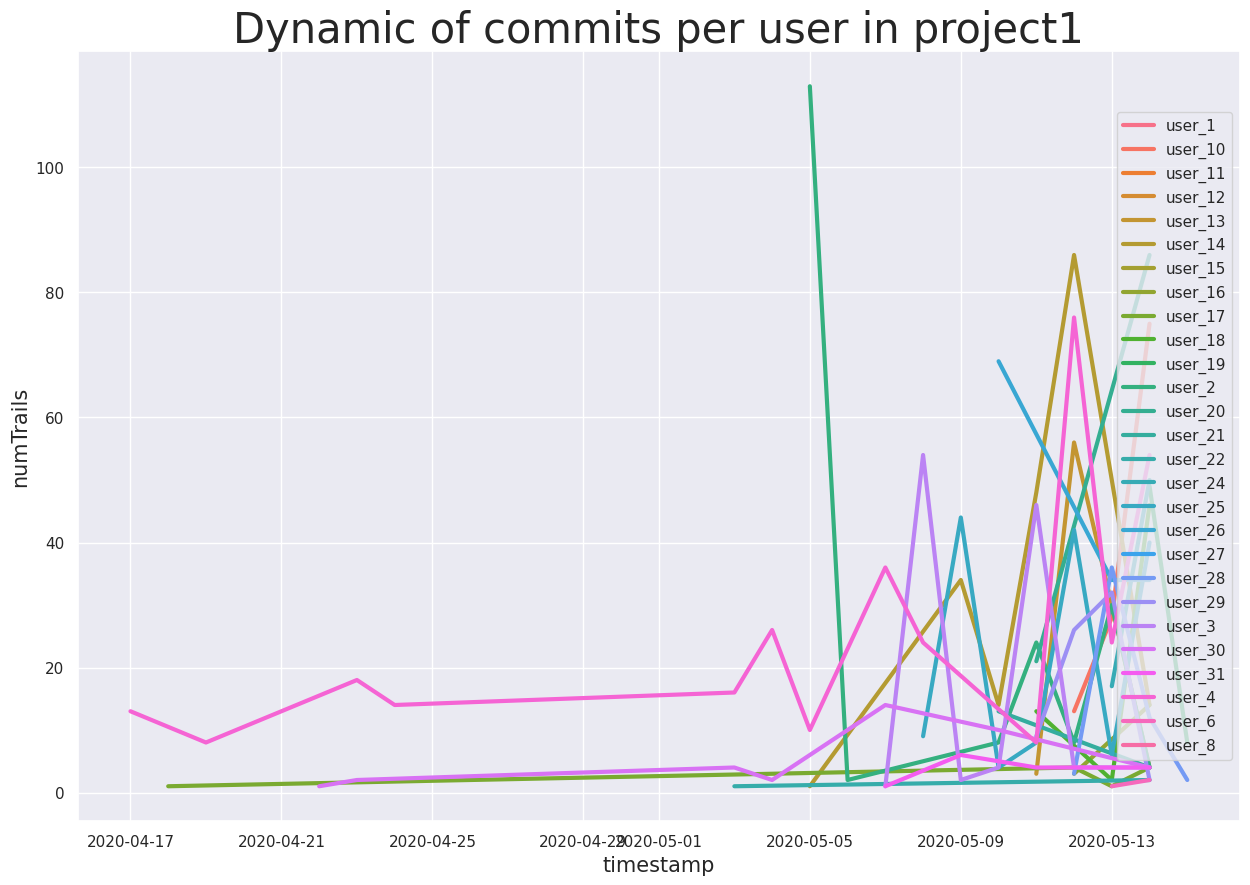

In [104]:
sns.set(style="darkgrid")

plt.figure(figsize=(15, 10))
sns.lineplot(df_ch_2, x='timestamp', y='numTrails', hue='uid', linewidth=3)

plt.title('Dynamic of commits per user in project1', fontsize=30)
plt.xlabel('timestamp', fontsize=15)
plt.ylabel('numTrails', fontsize=15)
plt.legend(loc='right')

plt.show()